# Coherent and incoherent $J/\psi$ photoproduction on a proton

Run the cells in order with the project's Python environment. The main calculation is
$\gamma p\to J/\psi\,p$ and $\gamma p\to J/\psi\,Y$ at $W_{\gamma p}=75$ GeV,
$Q^2=0$, compared with **H1 2013**. A short **rho comparison with H1 2020** follows.

The proton is one parent nucleon at the origin, with a new hotspot configuration
in each event. We use the existing GBW profile
$$
D_p(x,r,b)=\sigma_0 N_{\rm GBW}(x,r)T_p(b),\qquad
\int d^2b\,T_p=1,\qquad \sigma_0=4\pi B_p.
$$
See [the proton prescription, Eq. 7](https://arxiv.org/html/2312.11320v2).

Both meson masses and transverse Gaus-LC presets now live in
**upcmodel/parameters.py**, using
[Kowalski, Motyka and Watt, Table 1](https://arxiv.org/html/hep-ph/0606272).
For $J/\psi$: $M_V=3.097$ GeV, $m_c=1.4$ GeV, $N_T=1.23$,
$R_T^2=6.5$ GeV$^{-2}$, and $\hat e_f=2/3$.
The existing JPSI_HS preset supplies $B_p=4.75$ and $B_{\rm hs}=0.8$ GeV$^{-2}$.
These are the current model choices, with no fit to the plotted data.

In [1]:
from pathlib import Path
from functools import partial
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from IPython.display import Markdown, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "upcmodel").is_dir())
sys.path.insert(0, str(ROOT))

from upcmodel.parameters import (
    GBW_PAPER,
    JPSI_HS, JPSI_GAUS_LC_PARAM, JPSI_MASS_GEV,
    RHO_HS, RHO_GAUS_LC_PARAM, RHO_MASS_GEV,
)
from upcmodel.geometry import sample_target_hotspots, transverse_grid
from upcmodel.amplitudes import (
    proton_dipole_profile, event_amplitude, momentum_transfer_grid,
)
from upcmodel.wavefunctions import gaus_lc_overlap_integral_z
from upcmodel.corrections import effective_lambda_from_samples, skewness_factor
from upcmodel.ensemble import amplitude_moments, photon_target_spectra

OUTPUT = ROOT / "notebooks/gamma_p_outputs"
OUTPUT.mkdir(exist_ok=True)

Choose the energy, ensemble size, and grids. Both mesons below reuse these grids.
The momentum vectors are $\boldsymbol\Delta=(q,0)$; the sampled ensemble is
rotationally invariant. Keep enough FFT momenta to cover H1's last $J/\psi$
dissociative bin, $|t|=8$ GeV$^2$.
`momentum_transfer_grid` supplies the FFT momenta in GeV so the overlap can
be prepared once before the event loop. The same selection is applied to F below.

In [2]:
W_GeV = 75.0
Q_GeV = 0.0
x = (Q_GeV**2 + JPSI_MASS_GEV**2) / (Q_GeV**2 + W_GeV**2)
N_EVENTS = 4096
rng = np.random.default_rng(20260920)
dlogx = 0.05

proton_positions = np.zeros((1, 3))       # one parent nucleon, in fm
r_fm = np.geomspace(0.001, 6.0, 201)
bx_fm, by_fm, _ = transverse_grid(half_width_fm=12.0, n_points=192)

delta = momentum_transfer_grid(bx_fm)
keep = (delta >= 0) & (delta <= 3.0)
q_GeV = delta[keep]
t_GeV2 = q_GeV**2
H_T = gaus_lc_overlap_integral_z(JPSI_GAUS_LC_PARAM, r_fm, q_GeV, Q_GeV, nz=64)

The package's `event_amplitude` runs the existing pipeline:
profile $D$, shape $(R,P)$ → FFT $F$, shape $(R,K)$ →
complex amplitude, shape $(K,)$ in GeV$^{-2}$.
Configure its fixed inputs once with `partial`; each event then supplies only
$x$, source centers, and weights. The overlap is reused across events.
The hotspot preset sets the Gaussian source width and the independent $\sigma_0$.

In [3]:
amplitude_on_grid = partial(
    event_amplitude,
    r_fm=r_fm, bx_fm=bx_fm, by_fm=by_fm,
    momentum_mask=keep, profile=proton_dipole_profile,
)
jpsi_amplitude = partial(
    amplitude_on_grid,
    overlap_H=H_T,
    profile_kwargs={
        "gbw_parameters": GBW_PAPER,
        "sigma_fm": np.sqrt(JPSI_HS.B_hs_fm2),
        "sigma_0_fm2": 4 * np.pi * JPSI_HS.B_p_fm2,
    },
)

Sample the $J/\psi$ proton ensemble and calculate all event amplitudes.
The resulting array has shape **(N_EVENTS, K)**. This is the calculation's
main loop; it can take a few minutes.

In [4]:
amplitudes = np.empty((N_EVENTS, len(q_GeV)), dtype=complex)
for event in range(N_EVENTS):
    centers, _, weights, _ = sample_target_hotspots(proton_positions, x, JPSI_HS, rng)
    amplitudes[event] = jpsi_amplitude(x, centers, weights)

Obtain one common skewness factor from the last event at two nearby $x$ values,
with its geometry frozen, using the forward amplitude. In this factorized
profile every normalized event has the same forward amplitude and slope.
The correction is applied once, at the cross-section level.

In [5]:
A_low_x = jpsi_amplitude(x * np.exp(-dlogx), centers, weights)[0]
A_high_x = jpsi_amplitude(x * np.exp(+dlogx), centers, weights)[0]
lambda_eff = effective_lambda_from_samples(A_low_x, A_high_x, dlogx=dlogx)
R_g = skewness_factor(lambda_eff)
print(f"J/psi: x = {x:.6g}   lambda_eff = {lambda_eff:.5f}   R_g = {R_g:.5f}")

J/psi: x = 0.00170514   lambda_eff = 0.15612   R_g = 1.14171


Average over **events**, retaining each momentum bin:
$$
\frac{d\sigma_{\rm coh}}{d|t|}=\frac{R_g^2}{16\pi}|\langle\mathcal A\rangle|^2,
\qquad
\frac{d\sigma_{\rm inc}}{d|t|}=\frac{R_g^2}{16\pi}
\left(\langle|\mathcal A|^2\rangle-|\langle\mathcal A\rangle|^2\right).
$$
The helpers return GeV$^{-4}$. Convert to **nb/GeV$^2$** for the $J/\psi$
data. No separate real-part correction or saturation-scale fluctuations are included.

In [6]:
mean_amplitude, variance = amplitude_moments(amplitudes)
coherent, incoherent = photon_target_spectra(mean_amplitude, variance, R_g=R_g)
GEV_MINUS2_TO_NANOBARN = 389379.3721
coherent *= GEV_MINUS2_TO_NANOBARN
incoherent *= GEV_MINUS2_TO_NANOBARN
spectra = {"el": coherent, "pd": incoherent}

## $J/\psi$: H1 elastic and proton-dissociative data

**H1 Collaboration**, *Elastic and Proton-Dissociative Photoproduction of
$J/\psi$ Mesons at HERA*, EPJ C **73** (2013) 2466, **Table 5**:
[paper](https://arxiv.org/html/1304.5162),
[DOI](https://doi.org/10.1140/epjc/s10052-013-2466-y),
[official numerical table](https://www-h1.desy.de/psfiles/figures/d13-058.table_tHE_allH1_v2.txt).

The local excerpt contains **8 elastic and 9 dissociative bins**. These are
photon-proton cross sections in nb/GeV$^2$; do not divide by a photon flux again.
The measured range is $40<W<110$ GeV, $Q^2<2.5$ GeV$^2$, with
$m_p<M_Y<10$ GeV for dissociation. The calculation uses real photons and the
representative $W=75$ GeV used in
[Mäntysaari–Schenke, Figure 7](https://arxiv.org/html/1607.01711);
it does not integrate over the experimental $W$ interval or predict $M_Y$.

Open squares are **model bin averages**. Compare those to the measured points;
horizontal bars show bin widths and vertical bars the official total uncertainties.
Model Monte Carlo uncertainties are not displayed. The two panels cover different
$|t|$ ranges because that is how the elastic and dissociative measurements are tabulated.

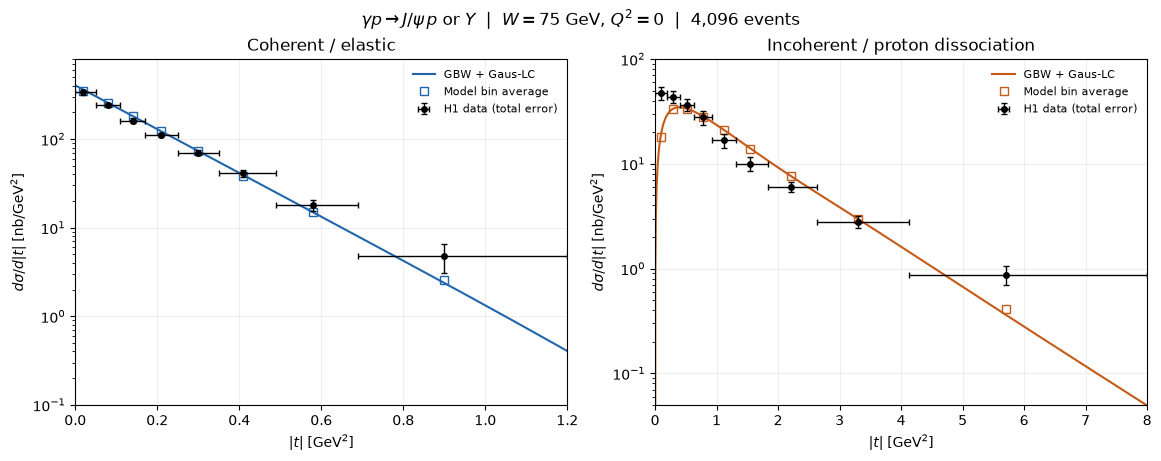

In [7]:
data_jpsi = np.genfromtxt(
    ROOT / "notebooks/data/h1_jpsi_W75.csv",
    delimiter=",", names=True, dtype=None, encoding="utf8",
)

def plot_comparison(spectra, data, *, title, unit, t_max, y_limits, filename):
    labels = {"el": "Coherent / elastic", "pd": "Incoherent / proton dissociation"}
    colors = {"el": "#2166ac", "pd": "#c65a16"}
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), layout="constrained")
    for ax, channel in zip(axes, ("el", "pd")):
        points = data[data["channel"] == channel]
        lo, hi, center = points["t_min"], points["t_max"], points["t_center"]
        curve = PchipInterpolator(t_GeV2, spectra[channel])
        model_bins = np.array([curve.integrate(a, b) / (b-a) for a, b in zip(lo, hi)])
        ax.plot(t_GeV2, spectra[channel], color=colors[channel], label="GBW + Gaus-LC")
        ax.plot(center, model_bins, "s", mfc="none", color=colors[channel], label="Model bin average")
        ax.errorbar(
            center, points["dsigma_dt"], xerr=[center-lo, hi-center],
            yerr=[points["err_minus"], points["err_plus"]],
            fmt="o", ms=4, color="black", lw=1, capsize=2, label="H1 data (total error)",
        )
        ax.set(
            title=labels[channel], xlabel=r"$|t|\;[\mathrm{GeV}^2]$",
            xlim=(0, t_max[channel]), ylim=y_limits[channel], yscale="log",
        )
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, frameon=False)
        ax.set_ylabel(r"$d\sigma/d|t|\;[" + unit + r"/\mathrm{GeV}^2]$")
    fig.suptitle(title)
    fig.savefig(OUTPUT / filename, dpi=180)
    plt.show()


plot_comparison(
    spectra, data_jpsi,
    title=rf"$\gamma p\to J/\psi\,p\ \mathrm{{or}}\ Y$  |  $W={W_GeV:g}$ GeV, $Q^2=0$  |  {N_EVENTS:,} events",
    unit=r"\mathrm{nb}", t_max={"el": 1.2, "pd": 8.0},
    y_limits={"el": (0.1, 800), "pd": (0.05, 100)},
    filename="jpsi_proton_h1.png",
)

Integrate each channel over **its own measured range**. The H1 totals below are
sums of the differential bins, not independent measurements. Their correlated
uncertainties are not propagated here; this is a direct comparison, not a fit.

In [8]:
table = ["| Channel | abs(t) range [GeV²] | Model [nb] | H1 bin sum [nb] | Model / H1 |",
         "|:--|:--|--:|--:|--:|"]
for channel, label in (("el", "Elastic"), ("pd", "Dissociative")):
    points = data_jpsi[data_jpsi["channel"] == channel]
    low, high = points["t_min"].min(), points["t_max"].max()
    model_total = PchipInterpolator(t_GeV2, spectra[channel]).integrate(low, high)
    data_total = np.sum(points["dsigma_dt"] * (points["t_max"] - points["t_min"]))
    table.append(f"| {label} | {low:g}–{high:g} | {model_total:.3f} | {data_total:.3f} | {model_total/data_total:.3f} |")
display(Markdown("\n".join(table)))

np.savez_compressed(
    OUTPUT / "jpsi_proton_spectra.npz",
    W_GeV=W_GeV, Q_GeV=Q_GeV, x=x, q_GeV=q_GeV, t_GeV2=t_GeV2,
    amplitudes_GeV_m2=amplitudes, mean_amplitude_GeV_m2=mean_amplitude, variance_GeV_m4=variance,
    coherent_nb_per_GeV2=coherent, incoherent_nb_per_GeV2=incoherent,
    lambda_eff=lambda_eff, R_g=R_g,
)

| Channel | abs(t) range [GeV²] | Model [nb] | H1 bin sum [nb] | Model / H1 |
|:--|:--|--:|--:|--:|
| Elastic | 0–1.2 | 70.754 | 68.685 | 1.030 |
| Dissociative | 0–8 | 53.885 | 59.118 | 0.911 |

## Afterward: the same calculation for $\rho^0$

Use **RHO_HS**, **RHO_GAUS_LC_PARAM**, and **RHO_MASS_GEV** from parameters.py.
This section reuses the same event-amplitude and plotting helpers.

Reference: **H1 Collaboration**, *Measurement of exclusive $\pi^+\pi^-$ and
$\rho^0$ meson photoproduction at HERA*, EPJ C **80** (2020) 1189,
**Tables 12 and 13**:
[paper](https://arxiv.org/abs/2005.14471),
[DOI](https://doi.org/10.1140/epjc/s10052-020-08587-3),
[official numerical data](https://www-h1.desy.de/psfiles/figures/d20-080.t12t13-rho-Wt_syst.csv).

Select $38<W<50$ GeV, with tabulated mean $W=44$ GeV and cross sections
quoted at $Q^2=0$. Dissociation has $m_p<M_Y<10$ GeV.
**The rho table uses microbarn/GeV$^2$, whereas the J/psi table uses nb/GeV$^2$.**
The rho Gaus-LC preset has $m_f=0.14$ GeV, $N_T=4.47$,
$R_T^2=21.9$ GeV$^{-2}$, and $\hat e_f=1/\sqrt2$, with $M_\rho=0.776$ GeV.

In [9]:
W_rho_GeV = 44.0
x_rho = (Q_GeV**2 + RHO_MASS_GEV**2) / (Q_GeV**2 + W_rho_GeV**2)
rng_rho = np.random.default_rng(20260920)
H_rho = gaus_lc_overlap_integral_z(RHO_GAUS_LC_PARAM, r_fm, q_GeV, Q_GeV, nz=64)
rho_amplitude = partial(
    amplitude_on_grid,
    overlap_H=H_rho,
    profile_kwargs={
        "gbw_parameters": GBW_PAPER,
        "sigma_fm": np.sqrt(RHO_HS.B_hs_fm2),
        "sigma_0_fm2": 4 * np.pi * RHO_HS.B_p_fm2,
    },
)

rho_amplitudes = np.empty((N_EVENTS, len(q_GeV)), dtype=complex)
for event in range(N_EVENTS):
    rho_centers, _, rho_weights, _ = sample_target_hotspots(proton_positions, x_rho, RHO_HS, rng_rho)
    rho_amplitudes[event] = rho_amplitude(x_rho, rho_centers, rho_weights)

rho_low_x = rho_amplitude(x_rho * np.exp(-dlogx), rho_centers, rho_weights)[0]
rho_high_x = rho_amplitude(x_rho * np.exp(+dlogx), rho_centers, rho_weights)[0]
rho_lambda = effective_lambda_from_samples(rho_low_x, rho_high_x, dlogx=dlogx)
rho_R_g = skewness_factor(rho_lambda)
rho_mean, rho_variance = amplitude_moments(rho_amplitudes)
rho_coherent, rho_incoherent = photon_target_spectra(rho_mean, rho_variance, R_g=rho_R_g)
GEV_MINUS2_TO_MICROBARN = 389.3793721
rho_spectra = {
    "el": rho_coherent * GEV_MINUS2_TO_MICROBARN,
    "pd": rho_incoherent * GEV_MINUS2_TO_MICROBARN,
}
print(f"rho: x = {x_rho:.6g}   lambda_eff = {rho_lambda:.5f}   R_g = {rho_R_g:.5f}")

rho: x = 0.000311041   lambda_eff = 0.03068   R_g = 1.02600


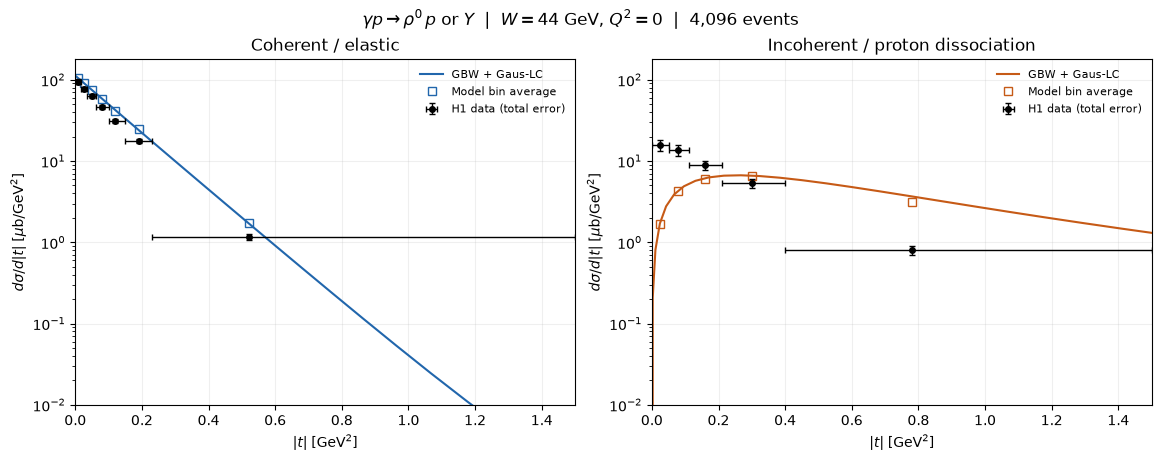

In [10]:
data_rho = np.genfromtxt(
    ROOT / "notebooks/data/h1_rho_W44.csv",
    delimiter=",", names=True, dtype=None, encoding="utf8",
)
plot_comparison(
    rho_spectra, data_rho,
    title=rf"$\gamma p\to\rho^0\,p\ \mathrm{{or}}\ Y$  |  $W={W_rho_GeV:g}$ GeV, $Q^2=0$  |  {N_EVENTS:,} events",
    unit=r"\mu\mathrm{b}", t_max={"el": 1.5, "pd": 1.5},
    y_limits={"el": (0.01, 180), "pd": (0.01, 180)},
    filename="rho_proton_h1.png",
)

np.savez_compressed(
    OUTPUT / "rho_proton_spectra.npz",
    W_GeV=W_rho_GeV, Q_GeV=Q_GeV, x=x_rho, q_GeV=q_GeV, t_GeV2=t_GeV2,
    amplitudes_GeV_m2=rho_amplitudes, mean_amplitude_GeV_m2=rho_mean, variance_GeV_m4=rho_variance,
    coherent_ub_per_GeV2=rho_spectra["el"], incoherent_ub_per_GeV2=rho_spectra["pd"],
    lambda_eff=rho_lambda, R_g=rho_R_g,
)

The current factorized, normalized profile forces the forward amplitude to be
identical in every geometric event, so its incoherent spectrum vanishes at $t=0$.
Agreement at moderate $|t|$ does not validate that limit. Rho production also
weights larger dipoles, making wavefunction and large-distance modeling more
important; see [Mäntysaari–Schenke, Sections VI.2–VI.3](https://arxiv.org/html/1607.01711).
The model has no breakup-mass selection, and its energy is a representative value.

The local data and their units, selections, and sources are documented in
[data/README.md](data/README.md). These are photon-target cross sections;
UPC photon fluxes, $P_{\rm nohad}$, and two-source interference enter later.

## What is saturation-scale variance?

At fixed $x$, the current GBW scale is deterministic:
$$
\overline{Q_s^2}(x)=Q_0^2(x_0/x)^\lambda.
$$
Geometry fluctuations move hotspots around. Saturation-scale fluctuations let
their gluon density, and therefore their scattering strength, vary as well.

A simple example assigns one positive random multiplier to each **whole event**:
$$
Q_{s,\omega}^2(x)=\overline{Q_s^2}(x)\,f_\omega,\qquad
f_\omega=\exp(sZ_\omega-s^2/2),\qquad Z_\omega\sim\mathcal N(0,1).
$$
Here $s$ is a dimensionless width of the log of $Q_s^2$. The subtraction
keeps the mean unchanged:
$$
\langle f\rangle=1,\qquad
\operatorname{Var}(Q_s^2)
=\bigl(\overline{Q_s^2}\bigr)^2(e^{s^2}-1).
$$
$Q_s^2$ has units GeV$^2$, and its variance has units GeV$^4$.
For $s=0.5$, the relative variance is $0.284$, and the relative standard
deviation is $0.533$. This parameter is unrelated to the transverse widths $B_p,B_{\rm hs}$.

In GBW the random scale would enter
$$
N_\omega(x,r)=1-\exp\!\left[-\frac{(r/\hbar c)^2Q_{s,\omega}^2(x)}4\right].
$$
Even with positions fixed, different events then give different forward amplitudes
and can generate nonzero forward incoherent scattering. Keeping the mean $Q_s^2$
fixed does not keep the mean amplitude fixed, because $N$ is nonlinear.

The literature also uses an independent factor for each hotspot or transverse
cell; that has different spatial correlations from the whole-event example.
See [Mäntysaari–Schenke, Section V and Figure 10](https://arxiv.org/html/1607.01711).
Such an extension needs an explicit choice of where the fluctuating scale enters
the profile; simply renormalizing every event's weights back to unit sum retains
the current fixed forward strength.

**This is an explanation of a possible next model ingredient. No saturation-scale
fluctuations are included in either calculation above.**